In [1]:
from scipy.optimize import minimize
from scipy.optimize import direct, Bounds
from smooth_POD_ROM.post_processing import richardson_lucy, get_sigma, relative_distance_nearest_neighbour
from smooth_POD_ROM.pre_processing import smoothen_rowwise
from smooth_POD_ROM.reduced_order_model import get_predictions, get_improvement
from smooth_POD_ROM.reduced_order_model import train_ROM_rw, L2_error_rw
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
cmap = plt.colormaps.get_cmap("plasma")
single_column = 90  # mm
font_size_normal = 8

single_column_in = single_column/10/2.54
fw, fh = single_column_in, single_column_in/1.618
single_column_figure = (fw, fh)

plt.rcParams['font.size'] = font_size_normal
plt.rcParams["figure.figsize"] = single_column_figure

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['legend.labelspacing'] = 0.25
plt.rcParams['legend.handlelength'] = 1.5
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=font_size_normal, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 40

In [3]:

# n_x = 1000
# x = np.linspace(0, 1, n_x, endpoint=False)
case = {
    # "n_x": n_x,
    # "shape": x.shape,
    # "x": x,
    # "dx": x[1] - x[0],

    "n_train": 50,
    "n_test": 25,  # 25
    "g": None, #small_saw_tooth, #saw_tooth, #rectangular_pulse,step
    "truncate": 8,
    "sigma": 0.026,

    "c": 0,
    "monitor_progress_postprocessing": False,
    "num_iter": 10,
    "monitor_convergence": False,
    "sROM_only": False,
    "sigmaD": "calc_based_on_distance",
}

In [4]:
def solve_burgers_1d(nu, L, T_final, Nx, Nt, pulse_start, pulse_end, pulse_amp, base_velocity):
    """
    Solves the 1D Viscous Burgers' Equation using an explicit finite difference scheme.

    Args:
        nu (float): Kinematic viscosity (nu).
        L (float): Length of the domain.
        T_final (float): Total simulation time.
        Nx (int): Number of spatial grid points.
        Nt (int): Number of time steps.
        pulse_start (float): Starting position of the initial pulse.
        pulse_end (float): Ending position of the initial pulse.
        pulse_amp (float): Amplitude of the initial pulse.
    """
    # 1. Grid Setup and Parameters
    dx = L / (Nx - 1)
    dt = T_final / Nt
    x = np.linspace(0, L, Nx)

    # Stability Check (Basic, simplified CFL for demonstration)
    u_max = pulse_amp
    if u_max * dt / dx > 1.0 or nu * dt / (dx**2) > 0.5:
        print(f"Warning: CFL condition violated for advection or diffusion.")
        print(f"Current u*dt/dx: {u_max * dt / dx:.3f}, nu*dt/dx^2: {nu * dt / (dx**2):.3f}")
        print("Results may be unstable or inaccurate.")

    # 2. Initial Condition (Pulse)
    u = np.ones(Nx, dtype=np.float64) * base_velocity  # Base velocity
    u[(x >= pulse_start) & (x <= pulse_end)] = pulse_amp + base_velocity

    # 2. Initial Condition (wave)
    L = pulse_end - pulse_start
    l = (x >= pulse_start) & (x <= pulse_end)
    u[l] = (1.0 - np.cos((x[l] - pulse_start) * 2.0 * np.pi / L)) / 2.0 * pulse_amp + base_velocity

    # # gauss
    # x0 = (pulse_start + pulse_end) / 2.0  # Center the Gaussian
    # sigma = (pulse_end - pulse_start) / 4.0  # Width
    # u = np.ones(Nx, dtype=np.float64) * base_velocity
    # u += pulse_amp * np.exp(-(((x - x0) / sigma) ** 2))

    # Ensure U_MAX is still correctly calculated for stability (max value is at x0)
    # U_MAX = pulse_amp + base_velocity

    # Apply periodic boundary conditions for simplicity in the scheme
    # Note: Periodic BCs are implicitly handled by wrapping in the loop (u[i] vs u[i-1])

    # 3. Simulation and Snapshot Storage
    u_hist = []
    snapshot_count = 10
    snapshot_interval = Nt // (snapshot_count - 1)  # Including t=0 snapshot

    # Initialize the solution for the time loop
    u_n = u.copy()
    X = np.empty((Nt, Nx))
    X[0] = u_n
    for n in range(Nt - 1):
        if n % snapshot_interval == 0:
            u_hist.append(u_n.copy())

        # Create a new array for the n+1 step
        u_np1 = u_n.copy()

        # Explicit Euler time step
        for i in range(1, Nx - 1):

            # Convective term (Non-linear Upwind: uses u_i * (u_i - u_{i-1})/dx)
            convective_term = u_n[i] * (u_n[i] - u_n[i - 1]) / dx

            # Viscous term (Central Difference)
            viscous_term = nu * (u_n[i + 1] - 2 * u_n[i] + u_n[i - 1]) / (dx**2)

            # Update
            u_np1[i] = u_n[i] - dt * convective_term + dt * viscous_term

        # Update boundary conditions (Periodic)
        u_np1[0] = u_np1[Nx - 2]  # Set left boundary equal to the second-to-last inner point
        u_np1[Nx - 1] = u_np1[1]  # Set right boundary equal to the second inner point

        u_n = u_np1
        X[n + 1] = u_np1
    return x, X


In [5]:

# Define physical and numerical parameters:
nu = 0.001  # Viscosity (small for shock-like behavior)
L = 8  # Domain size [0, 2]
T_final = 10  # Run time
Nx = 1001  # Spatial resolution
# Nt = 11000  # Time steps (ensuring stability and resolution)
pulse_start = 0.5
pulse_end = 1
pulse_amp = 1.0  # Maximum velocity
base_velocity = 0.5
U_MAX = pulse_amp + base_velocity  # Maximum velocity (from pulse amplitude)
# --------------------------------------------------------

# 1. Calculate Grid Spacing
DX = L / (Nx - 1)

# 2. Determine Maximum Stable Time Step (dt_max)
# a. CFL condition (Advection): dt_cfl <= DX / U_MAX
dt_cfl = DX / U_MAX

# b. Diffusive condition: dt_diff <= 0.5 * DX^2 / NU
dt_diff = 0.5 * (DX**2) / nu

print("dt cfl", dt_cfl)
print("dt diff", dt_diff)
dt = min(dt_cfl, dt_diff)/2

Nt = int(T_final / dt)
print("dt chosen", T_final / Nt)


x, X = solve_burgers_1d(nu=nu, L=L, T_final=T_final, Nx=Nx, Nt=Nt, pulse_start=pulse_start, pulse_end=pulse_end, pulse_amp=pulse_amp, base_velocity=base_velocity)


dt cfl 0.005333333333333333
dt diff 0.032
dt chosen 0.0026666666666666666


In [6]:
x_n = x/L
case["x"] = x_n
case["dx"] = x_n[1]-x_n[0]
case["n_x"] = len(x)
case["shape"] = x.shape

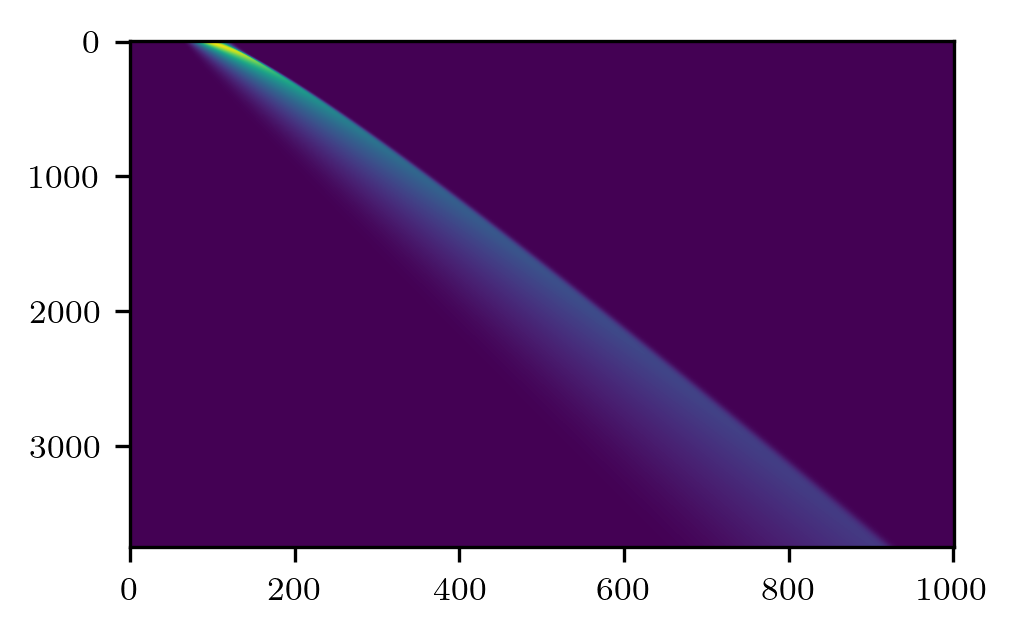

In [7]:
plt.imshow(X)
plt.gca().set_aspect("auto")
plt.show()

In [8]:
time = np.arange(0, T_final, dt)
X.shape, time.shape

((3750, 1001), (3750,))

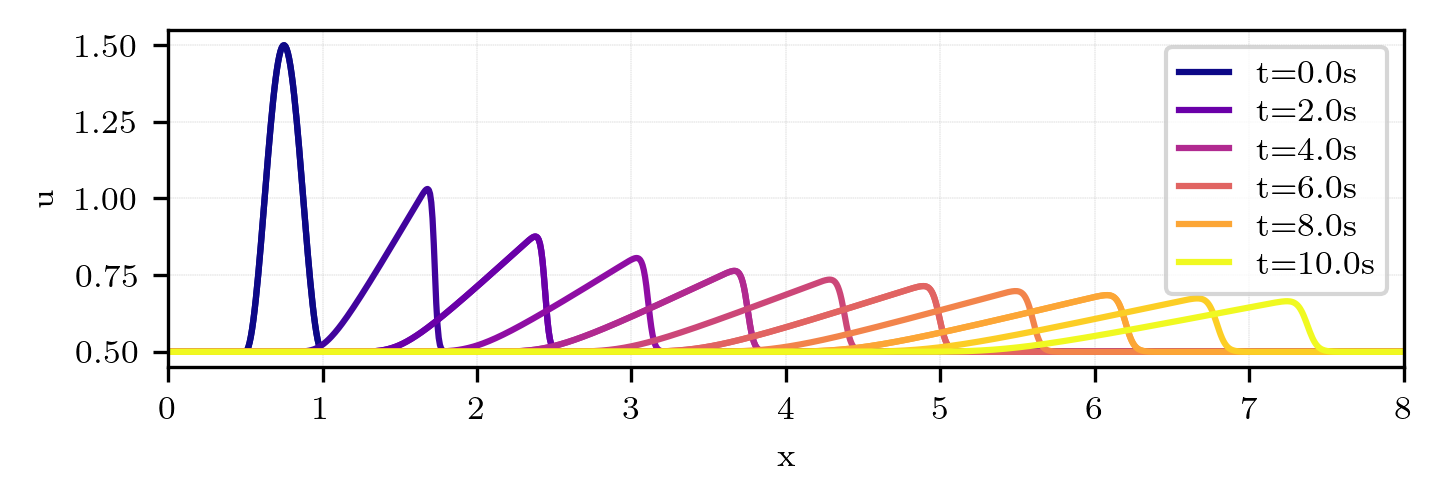

In [9]:
fig, ax = plt.subplots(figsize=(2*0.75*fw, fh/3*2))
time = np.arange(0, T_final, dt)
for j in range(0, Nt, Nt // 5):
    plt.plot(x, X[j], label=f"t={time[j]:.1f}s", color=cmap(j/Nt))
for j in range(0, Nt, Nt // 10):
    plt.plot(x, X[j], color=cmap(j/Nt))
plt.plot(x, X[-1], label=f"t={time[-1]:.1f}s", color=cmap(.9999))
#plt.title(f"1D Viscous Burgers Equation ($\\nu={nu}$)")
plt.xlabel("x")
plt.ylabel("u")
plt.grid(True, linestyle="--", lw=0.1)
plt.xlim(0, L)
plt.legend(loc="upper right")
#plt.ylim(base_velocity - 0.1, pulse_amp + base_velocity + 0.1)
plt.savefig("../Plots/Burgers1D_snapshots.pdf")
plt.show()

In [10]:
class Scaler:
    def __init__(self, data):
        vmin = data.min(axis=0)
        vmax = data.max(axis=0)
        vrange = vmax - vmin
        vrange[vrange < 1e-6] = 1e-6
        self.vmin = vmin
        self.vrange = vrange
        return

    def scale_down(self, data):
        return (data - self.vmin) / self.vrange

    def scale_up(self, data_n):
        return data_n * self.vrange + self.vmin

scaler = Scaler(X)
X_n = scaler.scale_down(X)
case["scaler"] = scaler

0.02967471


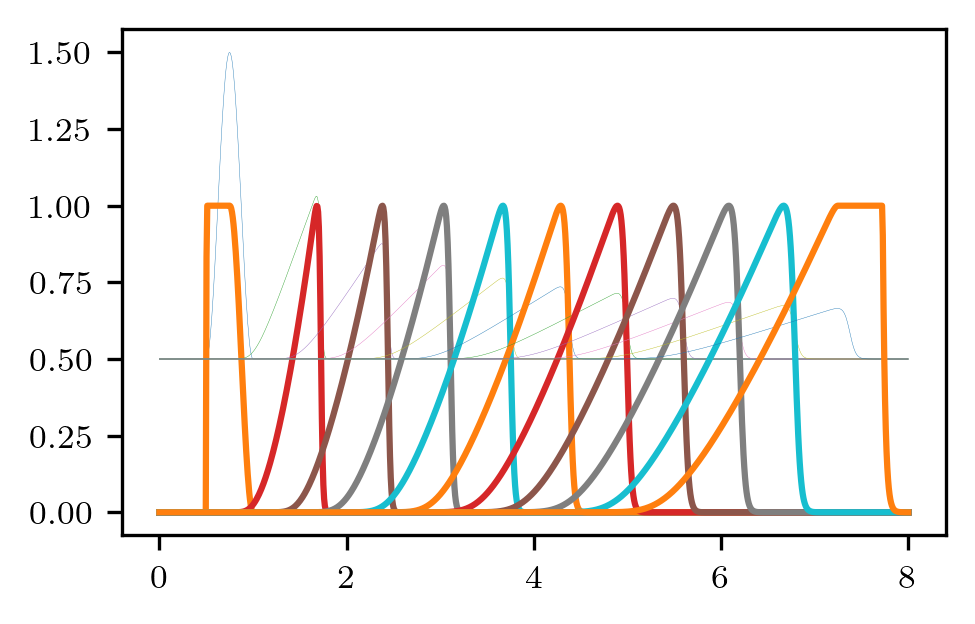

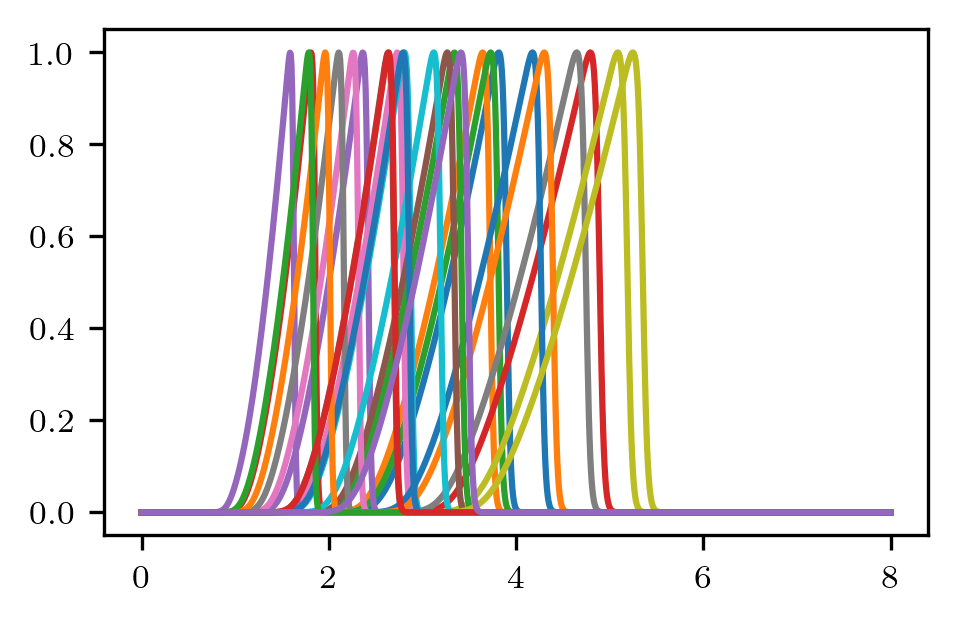

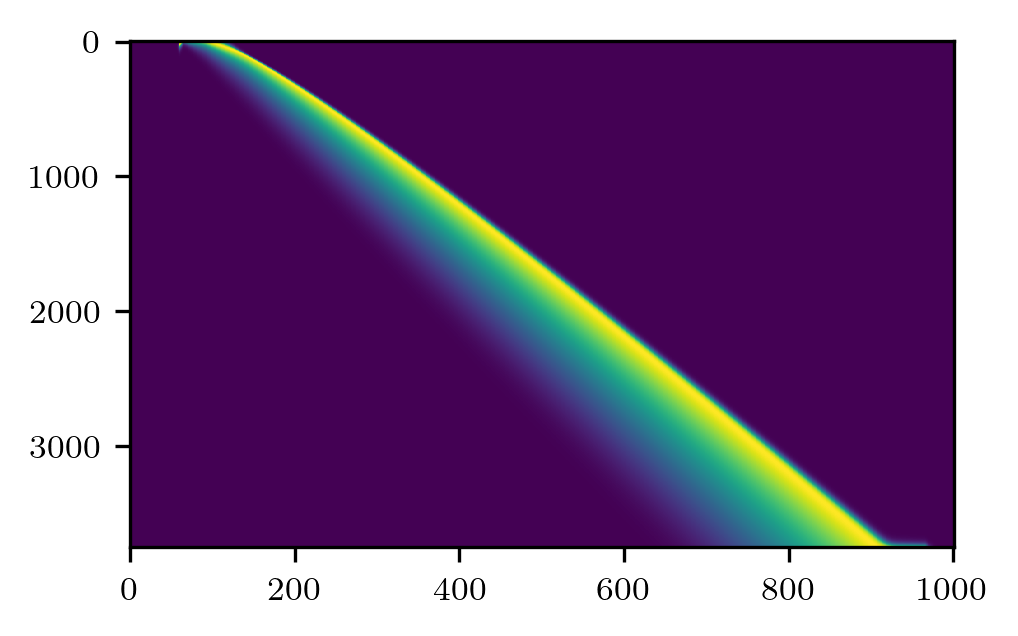

In [28]:
print(case["sigma"])
inds1 = np.array([*np.arange(0, Nt, Nt // 10), Nt-1])
X_train = X_n[inds1, :]
mu_train = time[inds1, None]
X_train_s = smoothen_rowwise(X_train, case["sigma"]/case["dx"], x.shape, truncate=case["truncate"], mode="wrap")
case["n_train"] = len(inds1)


case["n_test"] = 25
inds2 = np.random.randint(300, 2700, case["n_test"])
mu_test = time[inds2, None]
X_test = X_n[inds2]

X_val = X_n
mu_val = time[:, None]

for k in range(case["n_train"]):
    plt.plot(x, X[inds1[k]], lw=.1)
    plt.plot(x, X_train[k])
    #plt.plot(x, X_train_s[k])
plt.show()

for k in range(case["n_test"]):
    plt.plot(x, X_test[k])
plt.show()

plt.imshow(X_n, interpolation="nearest")
plt.gca().set_aspect("auto")
plt.show()

In [12]:
def target_function(mu_train, X_train, mu_test, X_test,  case):
    norm = case.get("norm", L2_error_rw)
    scaler = case.get("scaler", None)

    X_train_s = smoothen_rowwise(X_train, case["sigma"]/case["dx"], x.shape, truncate=case["truncate"], mode="wrap")


    # for k in range(case["n_train"]):
    #     plt.plot(x, X_train[k])
    #     plt.plot(x, X_train_s[k])
    # plt.show()
        
    # for k in range(case["n_test"]):
    #     plt.plot(x, X_test[k])
    # plt.show()
    # asd
    # print(X_train.shape, X_train_s.shape, mu_train.shape, X_test.shape, mu_test.shape)

    my_ROM = train_ROM_rw(mu_train, X_train)
    my_sROM = train_ROM_rw(mu_train, X_train_s)

    X_test_ROM = my_ROM.predict(mu_test).snapshots_matrix
    X_test_sROM, X_test_sROMs = get_predictions(my_sROM, mu_test, **case)
    mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(
        X_test, X_test_ROM, X_test_sROM, X_test_sROMs, norm=norm, scaler=scaler
    )
    print(
        "num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement"
    )
    if "sROM_only" in case.keys():
        if case["sROM_only"]:
            print(
                "{:.0f}, {:.0f}, {:.0f}, {:.8f}, -, {:.8f}, {:.8f}, -, {:.4f}".format(
                    case["num_iter"],
                    len(mu_train),
                    len(mu_test),
                    case["sigma"],
                    mean_ROM,
                    mean_sROM,
                    improvement,
                )
            )
            return mean_ROM, mean_sROM, mean_sROMs
    print(
        "{:.0f}, {:.0f}, {:.0f}, {:.8f}, {:.8f}, {:.8f}, {:.8f}, {:.8f}, {:.4f}".format(
            case["num_iter"],
            len(mu_train),
            len(mu_test),
            case["sigma"],
            case["c"],
            mean_ROM,
            mean_sROM,
            mean_sROMs,
            improvement,
        )
    )
    return mean_ROM, mean_sROM, mean_sROMs

In [13]:

def optimize_hyperparameters(mu_train, X_train, mu_test, X_test,  case):
    rank = case["rank"]
    sigma_opt = 0.2 / rank # 0.2optimal for saw tooth w=1/45

    def target(params):
        case["sigma"], case["c"] = params[0], params[1]
        return target_function(mu_train, X_train, mu_test, X_test,  case)[2]

    bounds = Bounds([0.001, 0], [5 * sigma_opt, 2])
    res = direct(target, bounds, eps=1e-2, len_tol=0.01)  # max side length_abs=[0.006, 0.25]
    print(
        "optimization result for sigma:",
        res["x"][0],
        "bounds",
        0.001,
        5 * sigma_opt,
        "guess:",
        sigma_opt,
    )
    print("optimization result for c:", res["x"][1], "bounds", 0, 2)
    print(res.message)
    # TODO: check if bounds were OK
    return res["x"]

In [15]:
case["rank"] = len(X_train)
optimize_hyperparameters(mu_train, X_train, mu_test, X_test,  case)

C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:34: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
10, 11, 25, 0.04595455, 1.00000000, 0.03523133, 0.03910633, 0.02484973, -29.4669
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
10, 11, 25, 0.07592424, 1.00000000, 0.03523133, 0.04700906, 0.02988347, -15.1793
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
10, 11, 25, 0.01598485, 1.00000000, 0.03523133, 0.03294478, 0.03522616, -0.0147
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
10, 11, 25, 0.04595455, 1.66666667, 0.03523133, 0.03910633, 0.02492068, -29.2656
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
10, 11, 25, 0.04595455, 0.33333333, 0.03523133, 0.03910633, 0.02725978, -22.6263
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
10, 11, 25, 0.07592424, 1.66666667, 0.035231

array([0.02967471, 1.99588477])

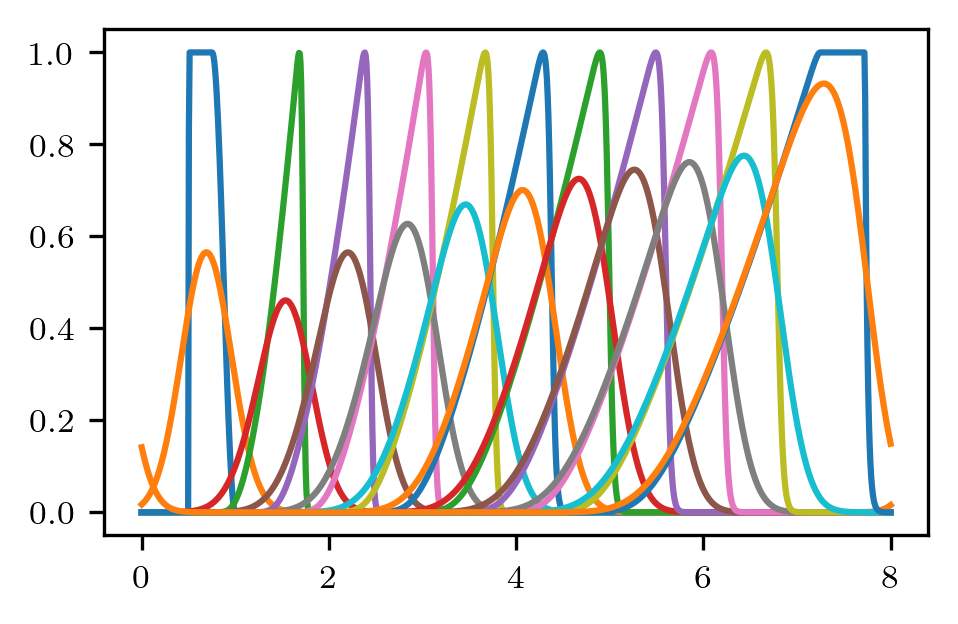

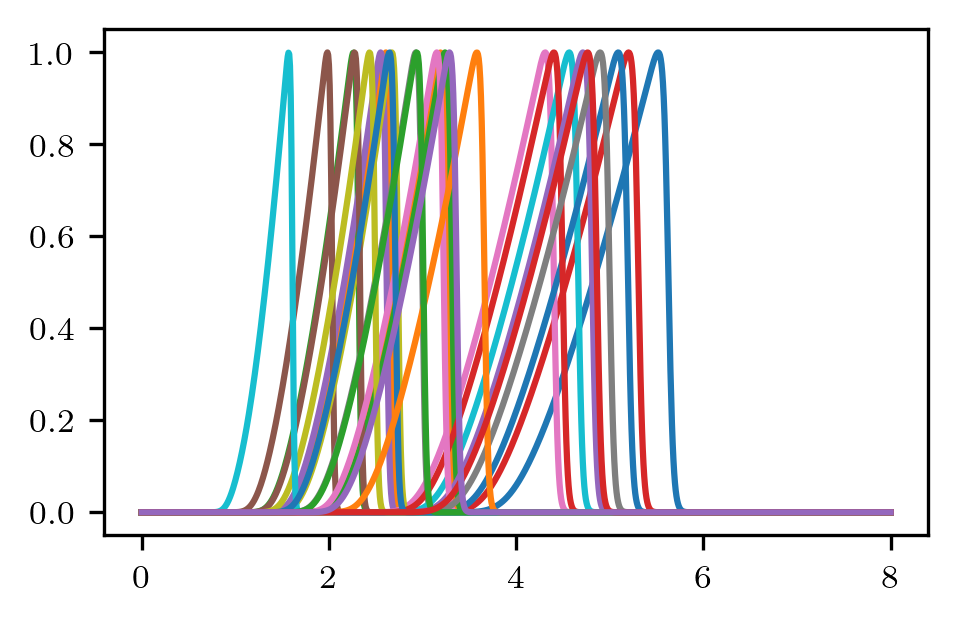

0 0.03220174154104176
1 0.04973302285701912
2 0.04025665457811246
3 0.058577633250665374
4 0.04483689924625066
5 0.05447120699647245
6 0.03188586259841152
7 0.03978283616416713
8 0.05557678329567823
9 0.05684029906619913
10 0.049101264971758644
11 0.0437313229470449
12 0.048469507086498206
13 0.04088841246337287
14 0.04736393078729245
15 0.03915107827890668
16 0.04025665457811244
17 0.029990588942630184
18 0.034254954668138216
19 0.03867725986496134
20 0.05320769122595155
21 0.038203441451016014
22 0.038835199336276466
23 0.042467807176524014
24 0.05289181228332134


In [21]:
case["sigma"] = 0.03485465768799103
case["c"] = 0.26748971193415644
num_iter = 250
case["sigma"] = 0.02967471
case["c"] = 1.99588477

X_train_s = smoothen_rowwise(X_train, case["sigma"]/case["dx"], x.shape, truncate=case["truncate"], mode="wrap")

for k in range(case["n_train"]):
    plt.plot(x, X_train[k])
    plt.plot(x, X_train_s[k])
plt.show()

for k in range(case["n_test"]):
    plt.plot(x, X_test[k])
plt.show()


my_ROM = train_ROM_rw(mu_train, X_train)
my_sROM = train_ROM_rw(mu_train, X_train_s)

X_test_ROM = my_ROM.predict(mu_test).snapshots_matrix
X_test_sROM, X_test_sROMs = get_predictions(my_sROM, mu_test, **case)


res = np.zeros((case["n_test"], case["n_x"], num_iter))
internal_error = np.zeros((case["n_test"], num_iter))
for k in range(case["n_test"]):
    sgm_est = get_sigma(case["sigma"], mu_test[k][None, ...], mu_train, c=case["c"])
    print(k, sgm_est)
    res[k], internal_error[k] = richardson_lucy(case["x"], X_test_sROM[k], sgm_est, num_iter, monitor_convergence=True)

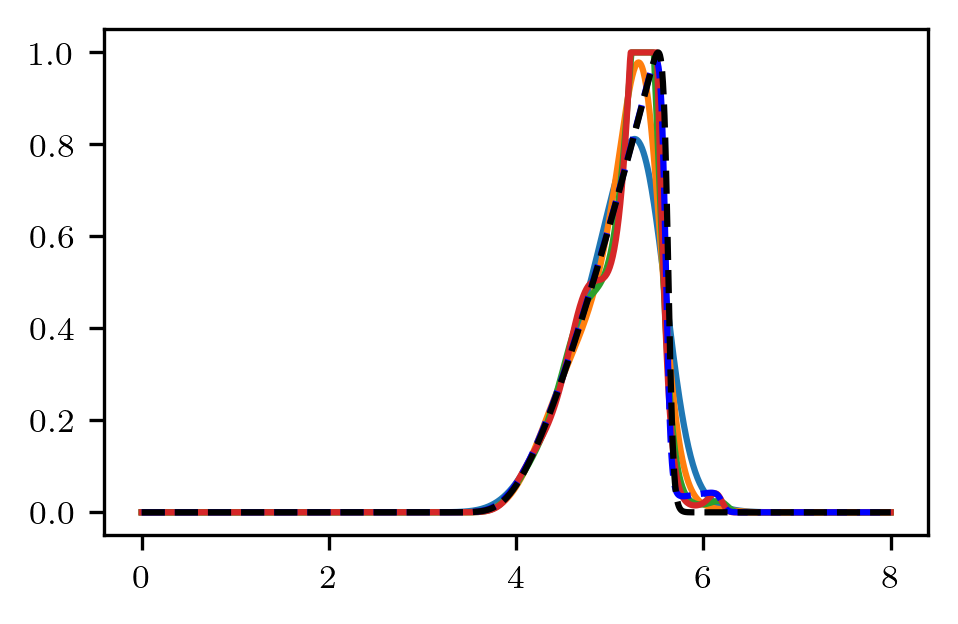

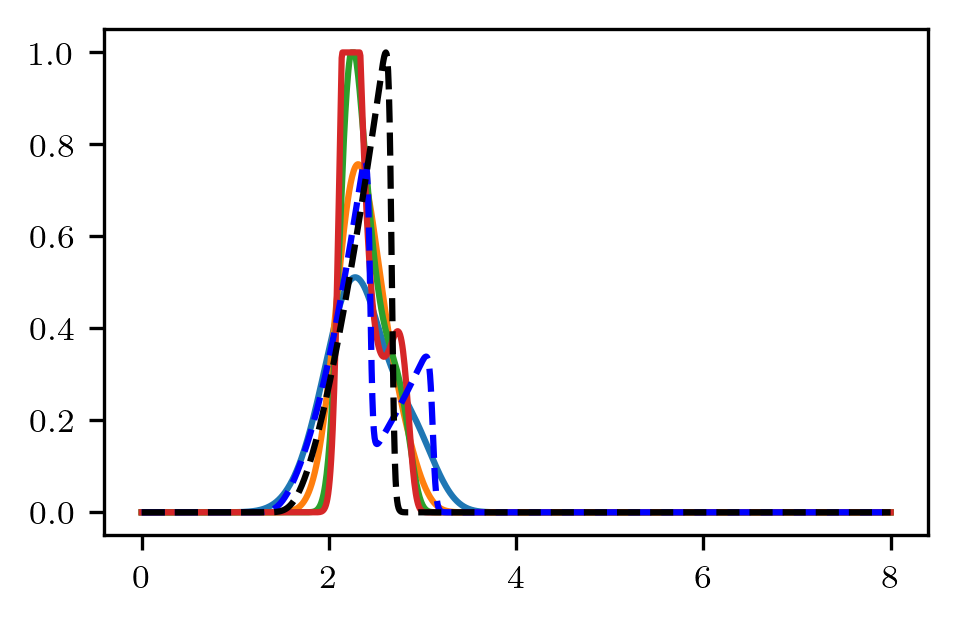

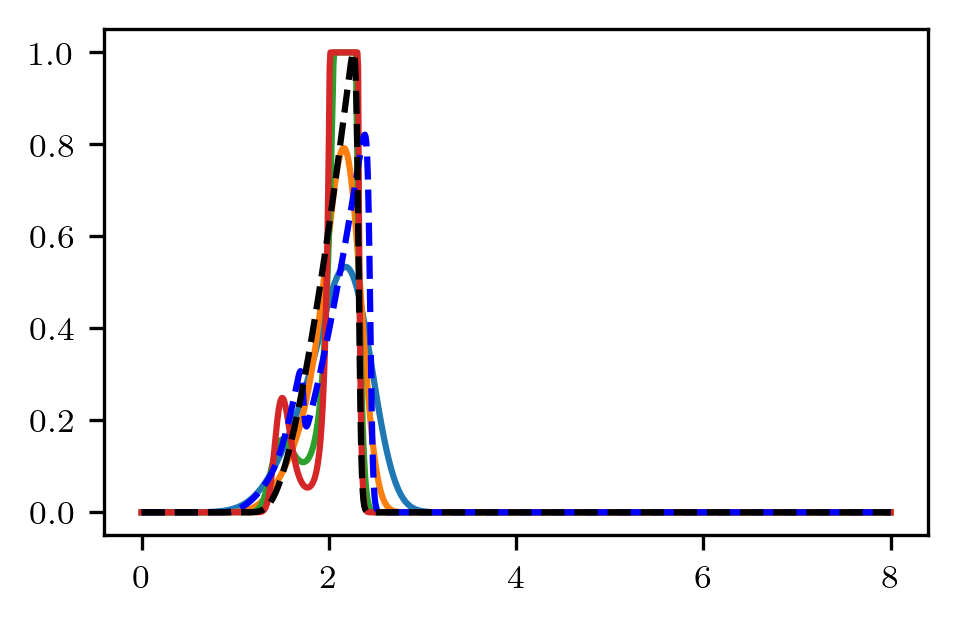

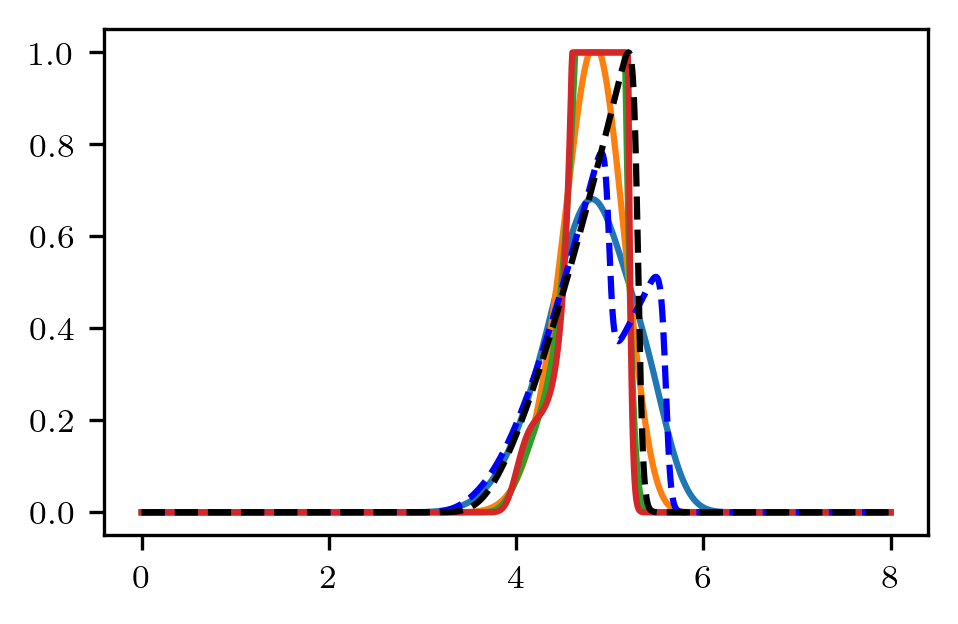

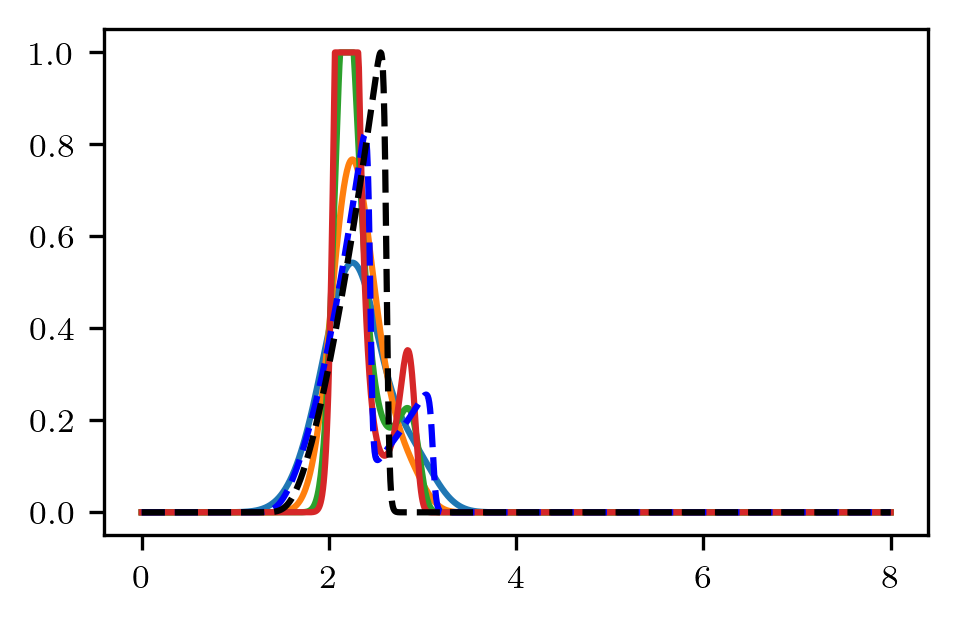

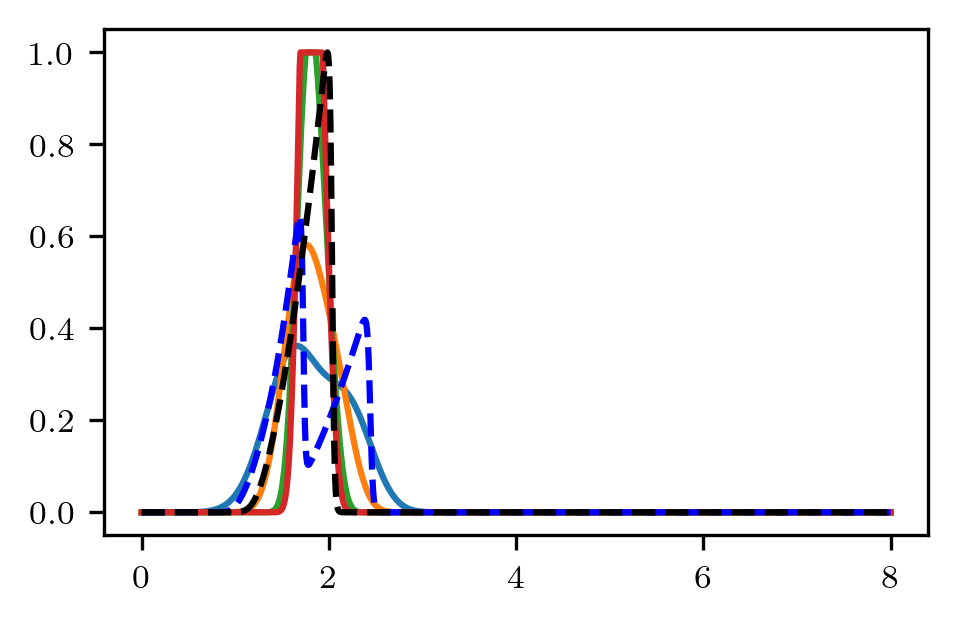

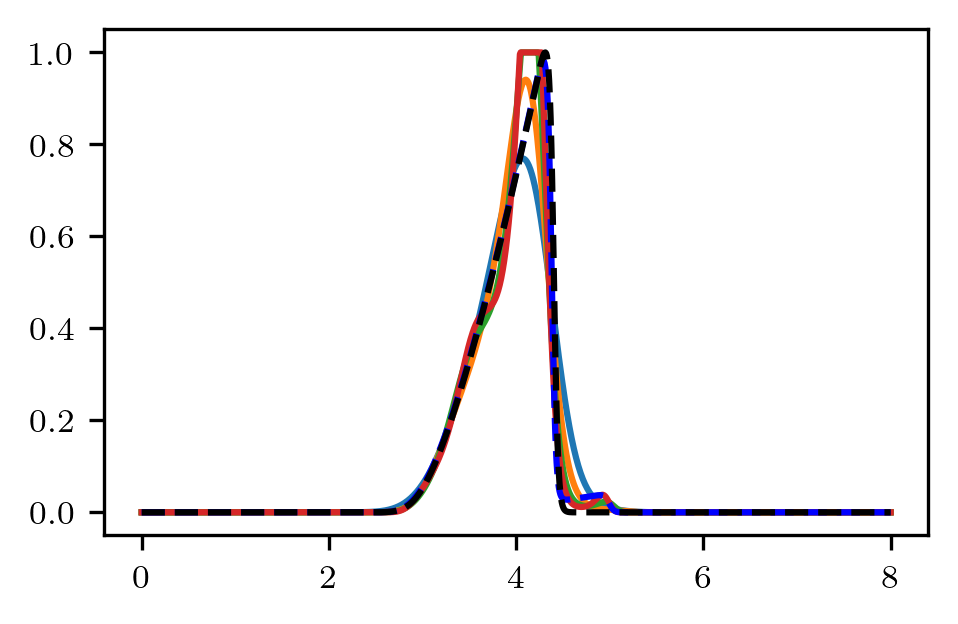

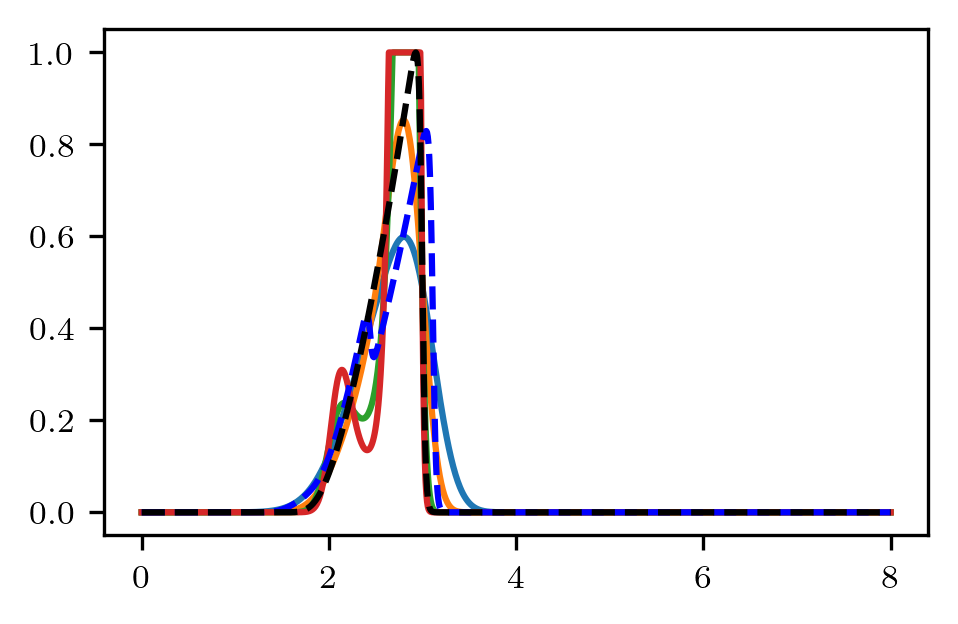

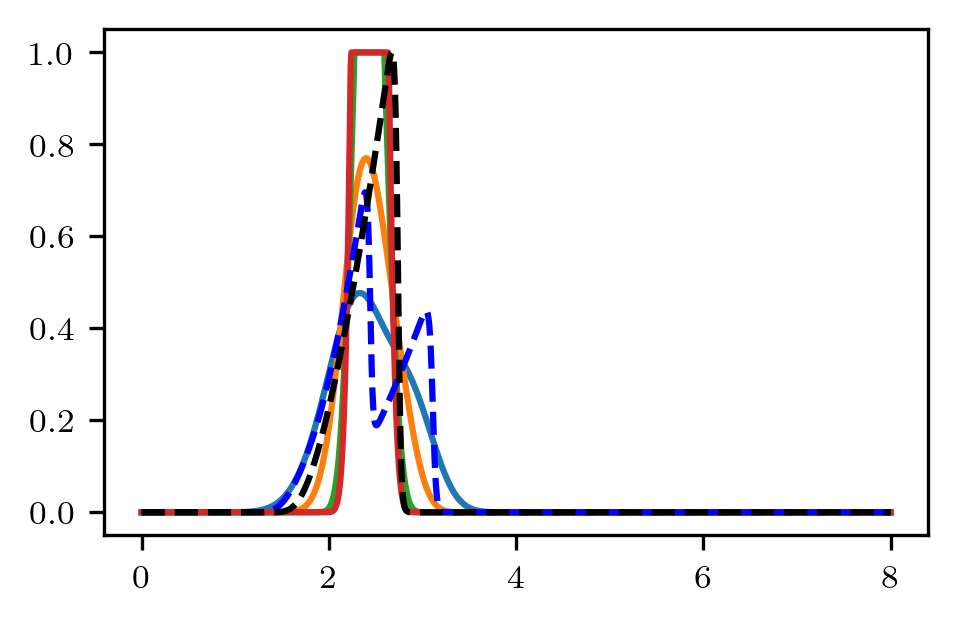

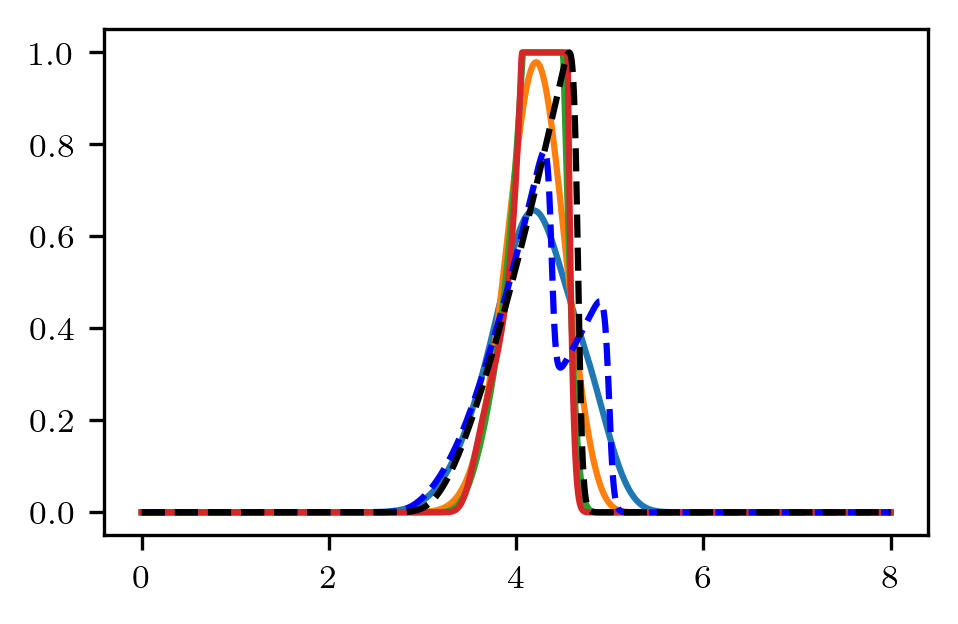

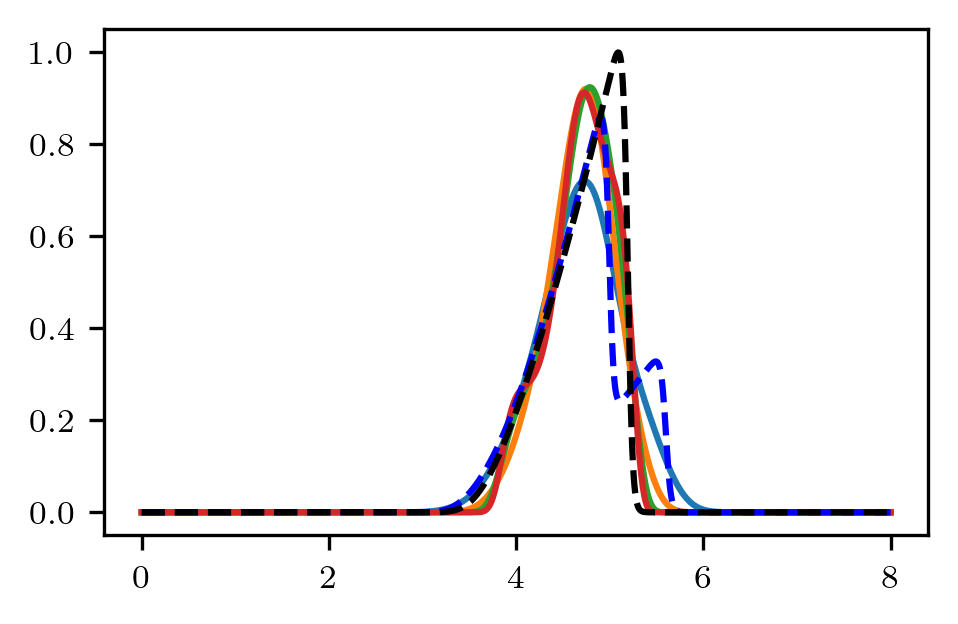

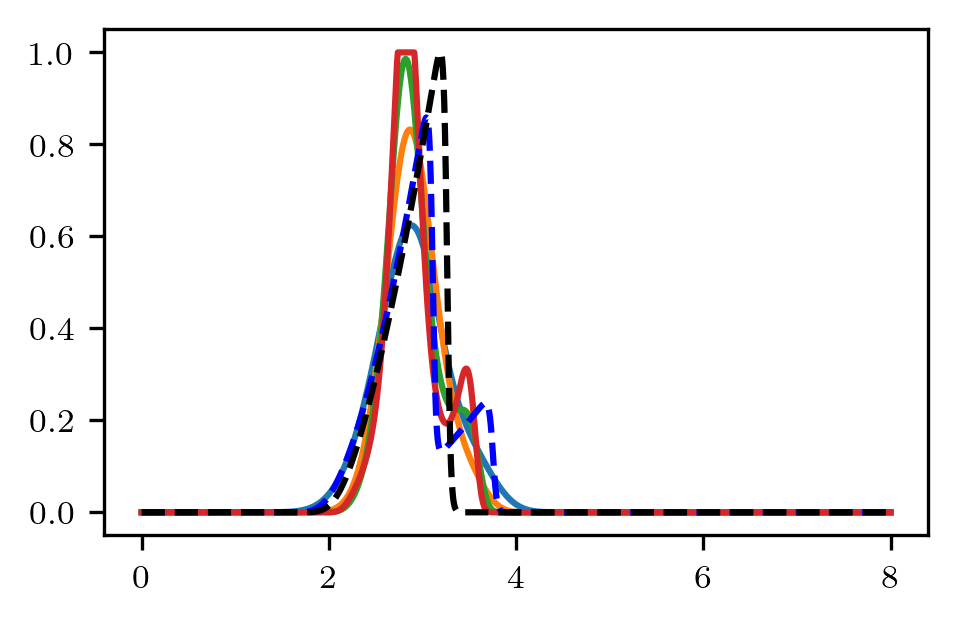

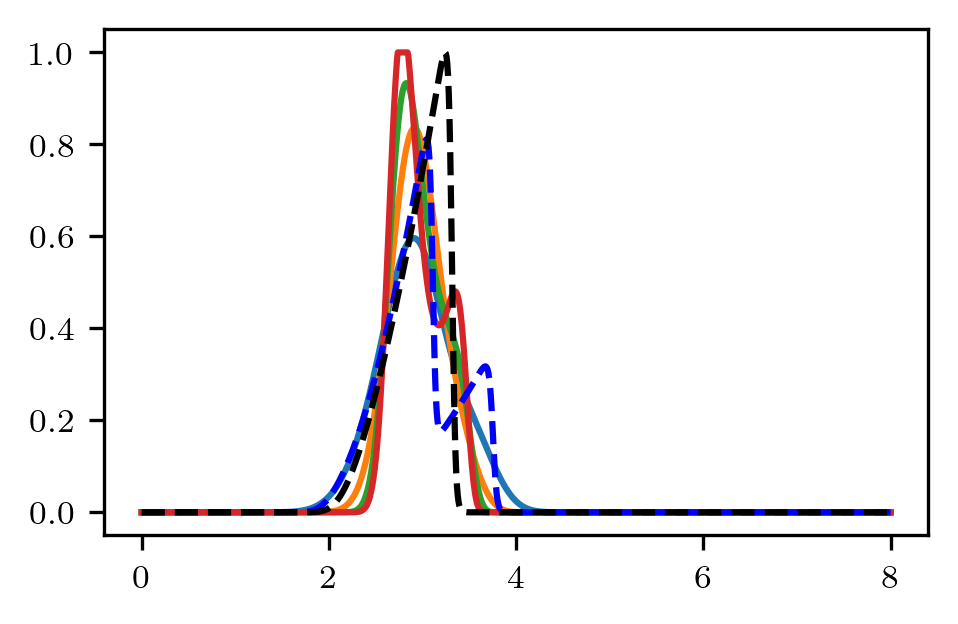

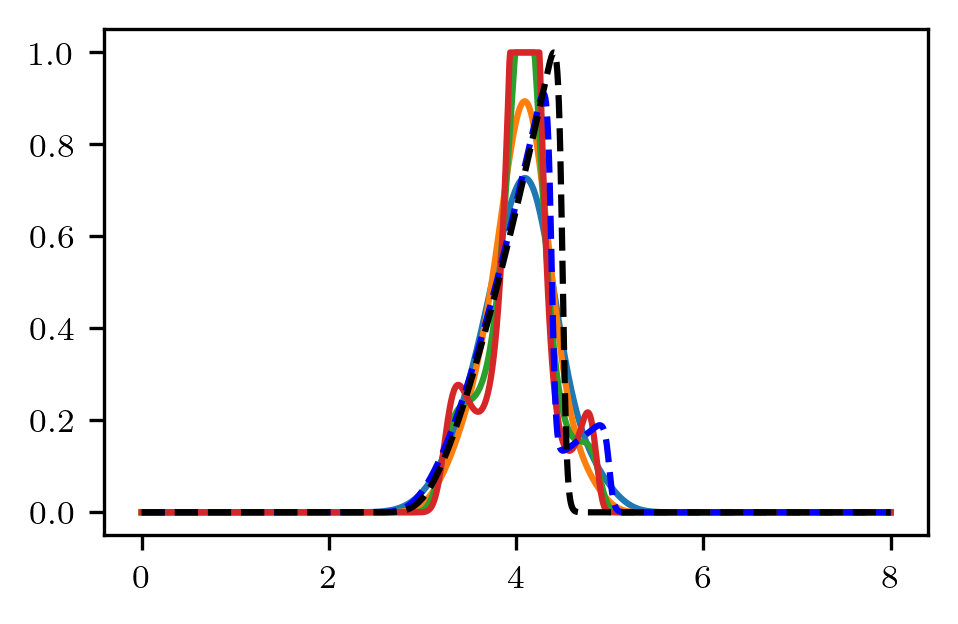

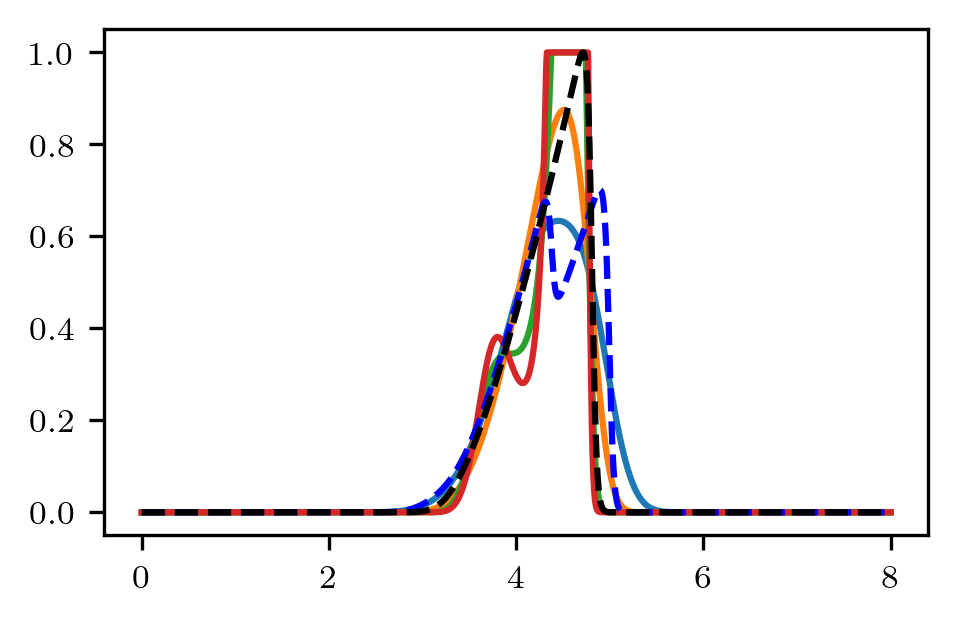

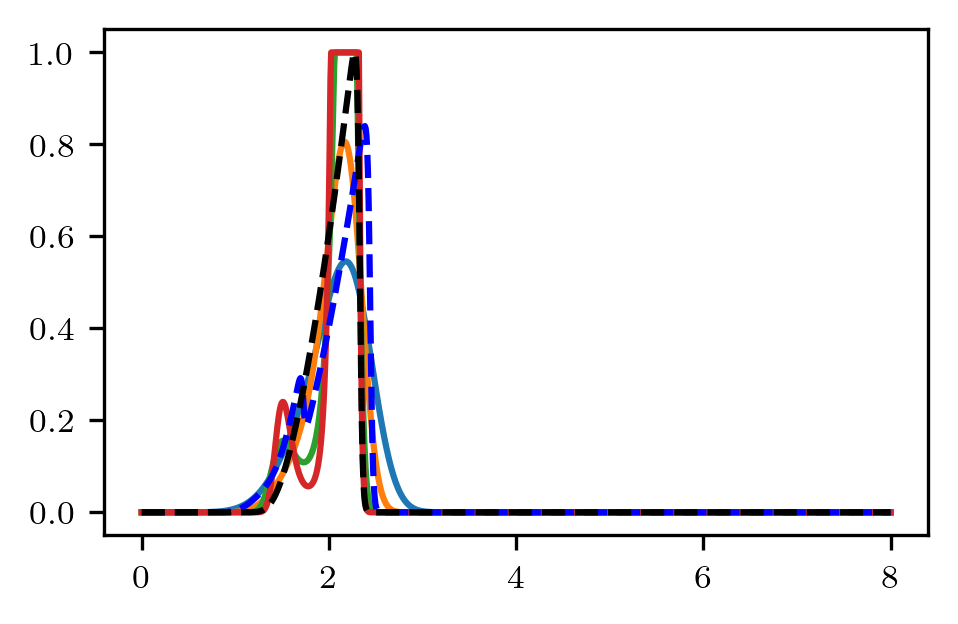

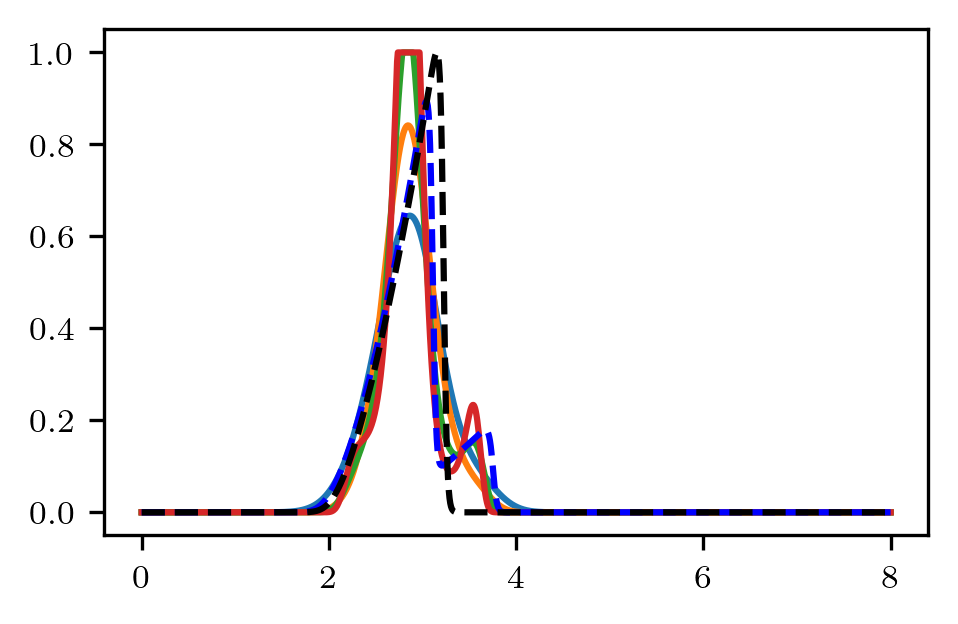

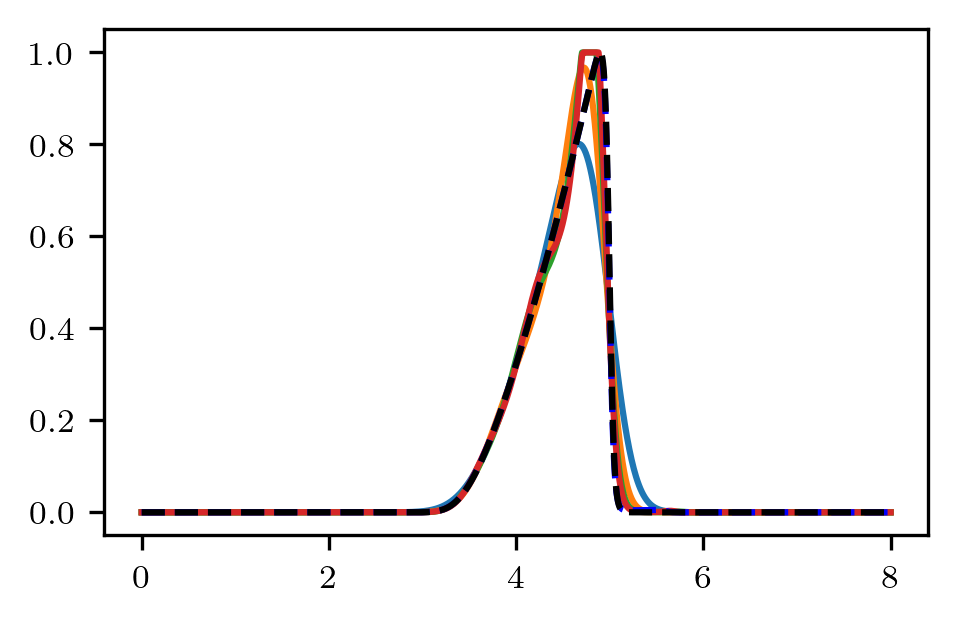

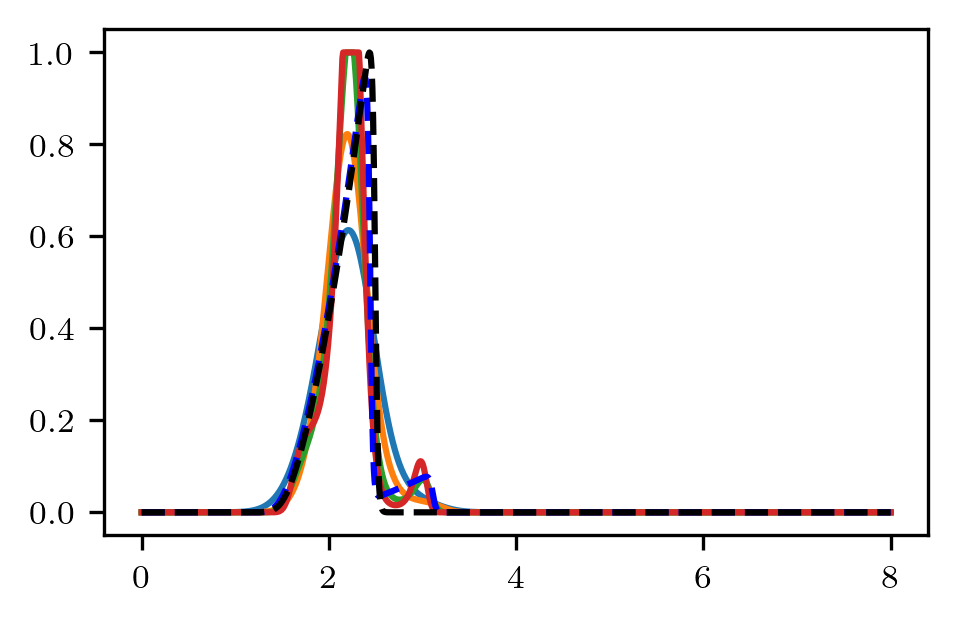

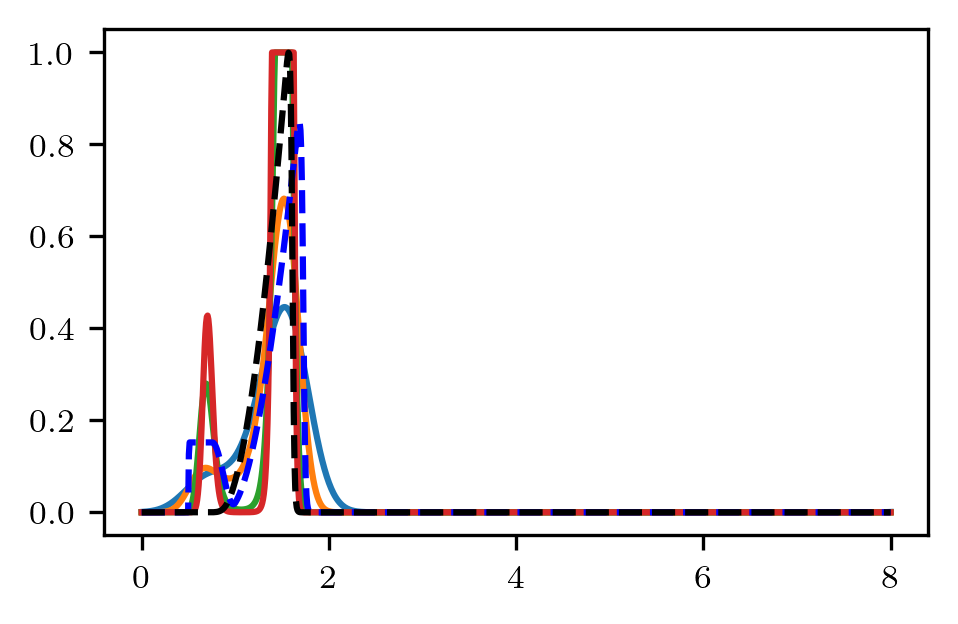

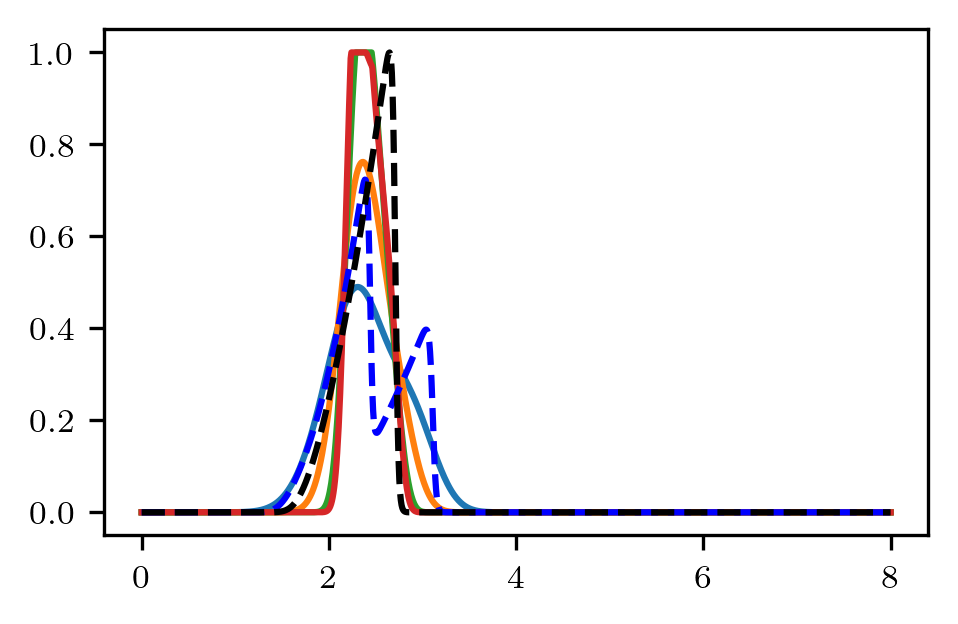

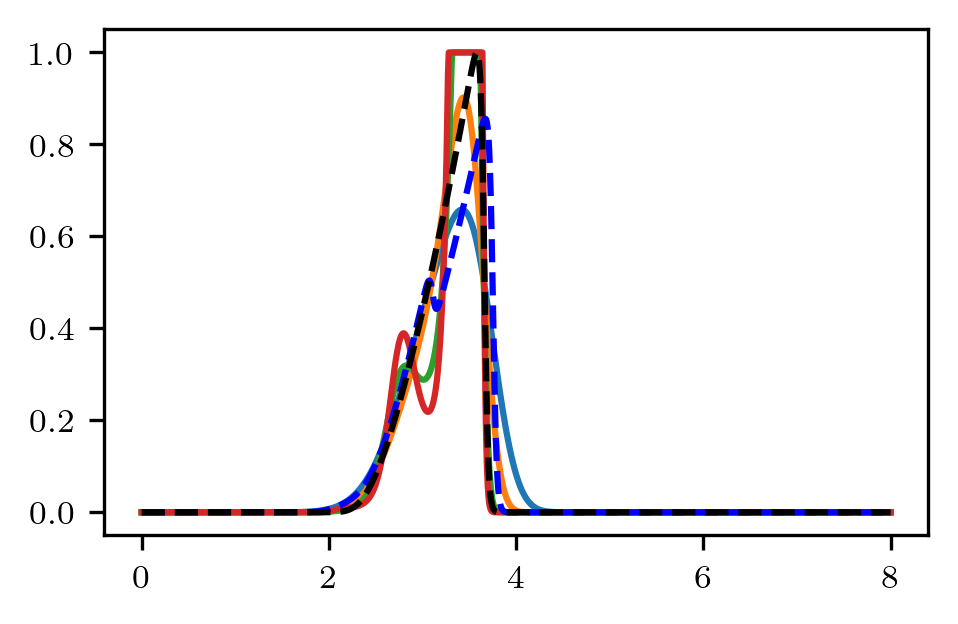

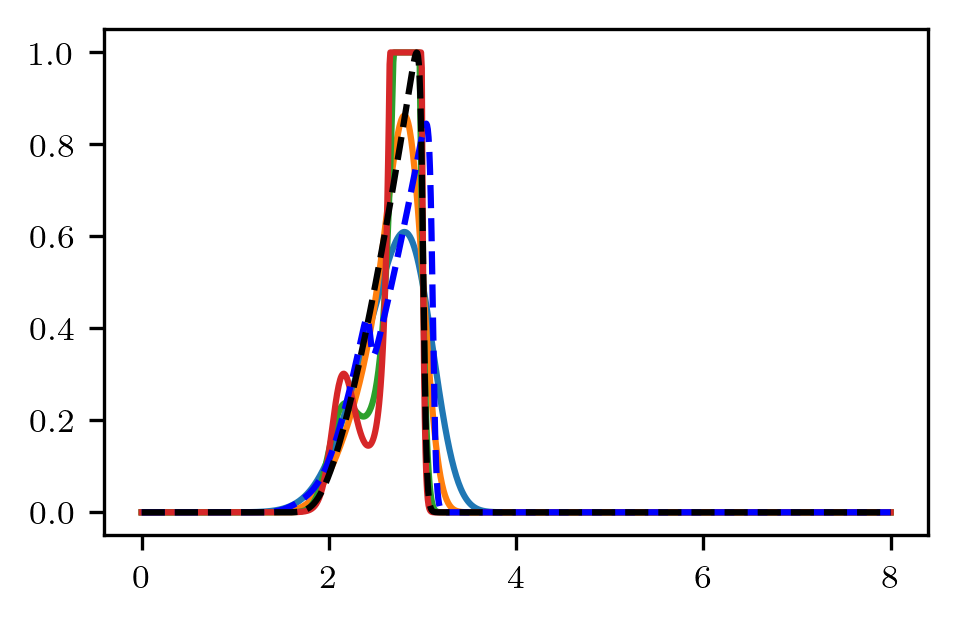

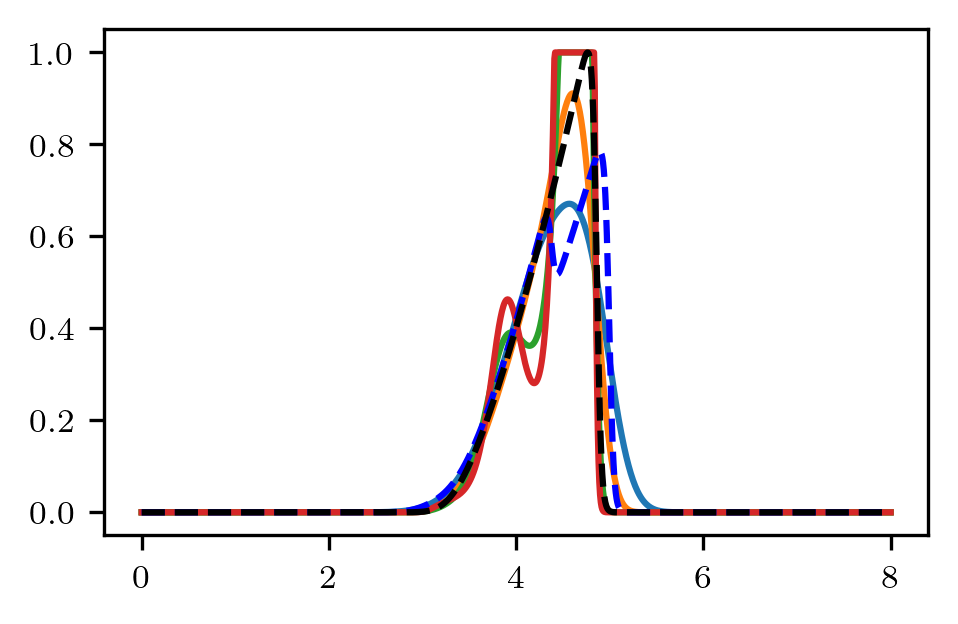

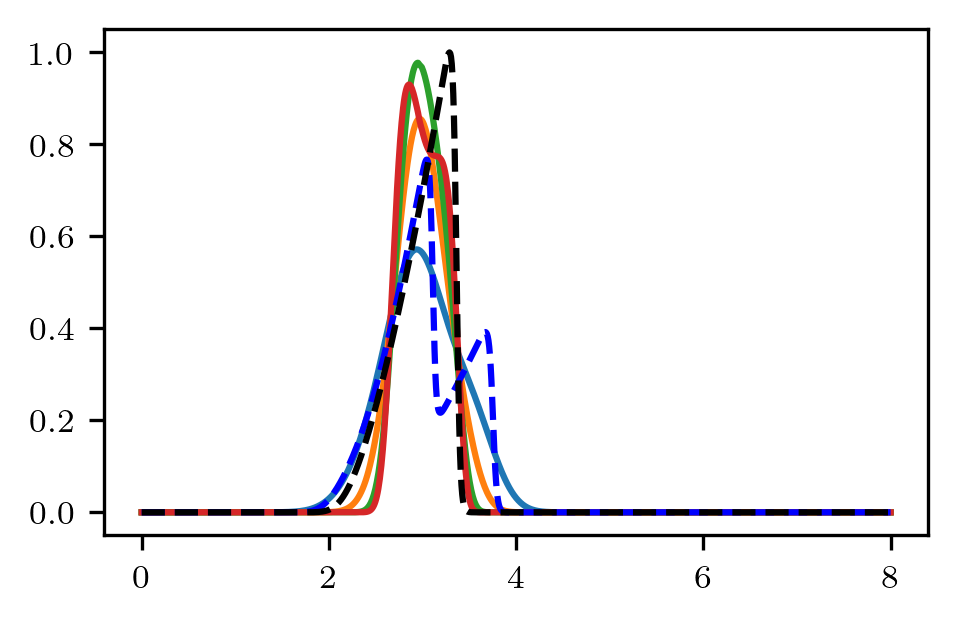

In [22]:
for k in range(case["n_test"]):
    plt.plot(x, res[k, :, 0])
    plt.plot(x, res[k, :, 10])
    plt.plot(x, res[k, :, 100])
    plt.plot(x, res[k, :, 249])
    plt.plot(x, X_test_ROM[k], "b--")
    plt.plot(x, X_test[k], "k--")
    plt.show()

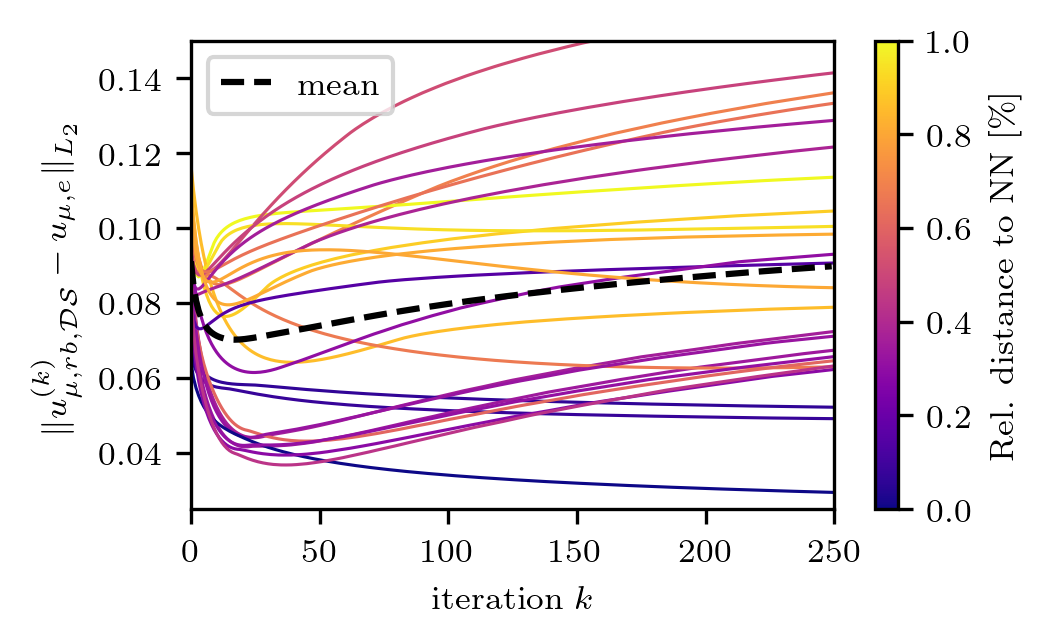

In [23]:
error = np.mean((X_test[:, :, None]-res) ** 2, axis=-2) ** 0.5

# color by relative distance of nearest neighbour of mu_test to mu_train
# compute distances per test sample and normalize to [0,1]
dists = np.array([
    relative_distance_nearest_neighbour(mu_test[k][None, ...], mu_train)
    for k in range(case["n_test"])
])
dmin = dists.min()
dptp = np.ptp(dists)
d_norm = (dists - dmin) / (dptp if dptp > 1e-12 else 1.0)

fig, ax = plt.subplots(figsize=(fw, fh))
for k in range(case["n_test"]):
    ax.plot(error[k], color=cmap(d_norm[k]), lw=.75)
ax.plot(np.mean(error, axis=0), "k--", label="mean")
plt.xlabel(r"iteration $k$")
plt.ylabel(r"$\|u_{\mu, rb, \mathcal{DS}}^{(k)} - u_{\mu, e}\|_{L_2}$")

# attach colorbar for relative distance mapping
norm = mpl.colors.Normalize(vmin=0.0, vmax=1.0)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r"Rel. distance to NN [\%]")
plt.legend()
ax.set_xlim(0, 250)
ax.set_ylim(0.025, 0.15)
plt.tight_layout()
plt.savefig("../Plots/Burgers1D_error_convergence.pdf")
plt.show()

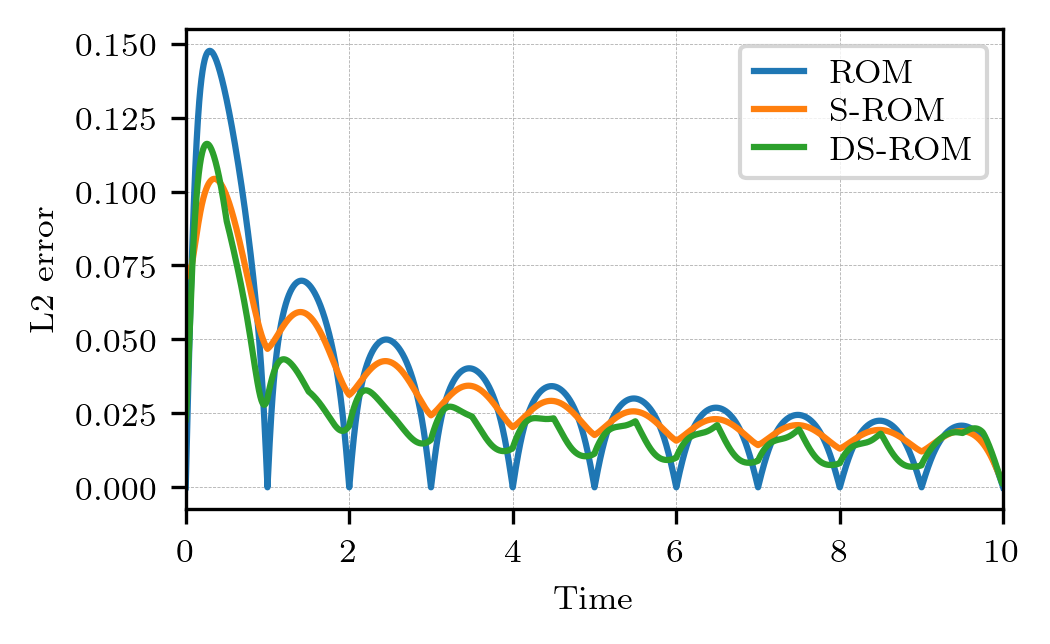

In [30]:
# Validation error vs time (mu)
# Predict on validation set and compute error over space at each time
X_val_ROM = my_ROM.predict(mu_val).snapshots_matrix
X_val_sROM, X_val_sROMs = get_predictions(my_sROM, mu_val, **case)

# Use same scaling and norm logic as in training/test
norm = case.get("norm", L2_error_rw)
scaler = case.get("scaler", None)
if scaler:
    X_val_orig = scaler.scale_up(X_val)
    X_val_ROM = scaler.scale_up(X_val_ROM)
    X_val_sROM = scaler.scale_up(X_val_sROM)
    X_val_sROMs = scaler.scale_up(X_val_sROMs)

# Errors per time (row-wise over space)
e_ROM = norm(X_val_ROM, X_val_orig, axis=1)
e_sROM = norm(X_val_sROM, X_val_orig, axis=1)
e_sROMs = norm(X_val_sROMs, X_val_orig, axis=1)

fig, ax = plt.subplots()
ax.plot(mu_val.ravel(), e_ROM, label="ROM")
ax.plot(mu_val.ravel(), e_sROM, label="S-ROM")
ax.plot(mu_val.ravel(), e_sROMs, label="DS-ROM")
ax.set_xlabel("Time")
ax.set_ylabel("L2 error")
ax.grid(True, linestyle="--", lw=0.2)
ax.legend()
plt.xlim(0, 10)
plt.tight_layout()
plt.savefig("../Plots/Burgers1D_error_validation.pdf")
